# Project 2: Predicting Calories in Food

## Problem Definition

The goal of this project is to predict the number of calories in a food using its nutritional information.

The target variable is calories.

This is a regression problem because calories are a numerical value.

This model could help people better understand how different nutrients relate to the calorie content of foods.

## Research Question

Can we predict the number of calories in a food based on its nutritional information?

## Background and Context

Calories measure the amount of energy provided by food. The main macronutrients that provide energy are carbohydrates, protein, and fat. Because these nutrients contribute to the energy content of foods, nutritional information can potentially be used to predict calorie values.

Understanding the relationship between nutrients and calories is useful because nutrition information is commonly used to compare foods and make dietary decisions. The USDA FoodData Central database provides detailed nutrient information for foods, making it useful for studying these relationships.

This project uses protein, carbohydrates, fat, fiber, and sodium as features to investigate whether machine learning can predict the calorie content of foods.

## Data Description

The data comes from the USDA FoodData Central Foundation Foods dataset.

Each row represents one food.

The target variable is calories.

The features used in the model are protein, carbohydrates, fat, fiber, and sodium.

After selecting Foundation Foods, there were 448 foods. After removing rows with missing values, 54 foods remained for modeling.

In [38]:
import os

print(os.getcwd())
print(os.listdir())

/Users/iniyasiva/Documents/ds-studio-ii
['food_nutrition_clean.csv', 'census_data.csv', 'movie_project.ipynb', 'api_activity.html', 'budget_vs_rating.png', 'nutrient.csv', 'food.csv', 'api_activity.ipynb', 'data_understanding_team_E.ipynb', 'team_E.csv', 'nutrition_project.ipynb', 'food_nutrient.csv', 'data_understanding_team_E.html', 'budget_vs_revenue.png', 'tmdb_movies_clean.csv', 'Python Exercise.html', '.gitignore', '.env', 'Python Exercise.ipynb']


In [39]:
import pandas as pd

food = pd.read_csv("food.csv")
food_nutrient = pd.read_csv("food_nutrient.csv")
nutrient = pd.read_csv("nutrient.csv")

/var/folders/p_/lyj_vyfn3_9b3r7pk30fmjfw0000gn/T/ipykernel_34856/3605455999.py:4: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  food_nutrient = pd.read_csv("food_nutrient.csv")


In [40]:
food.head()

,fdc_id,data_type,description,food_category_id,publication_date
0,319874,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
1,319875,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
2,319876,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
3,319877,sub_sample_food,Hummus,16.0,2019-04-01
4,319878,sub_sample_food,Hummus,16.0,2019-04-01


In [41]:
food_nutrient.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,2201847,319877,1051,56.30,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,2201845,319877,1002,1.28,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2,2201846,319877,1004,19.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,2201844,319877,1007,1.98,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,2201852,319878,1091,188.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [42]:
nutrient.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [43]:
print(food.columns)
print(food_nutrient.columns)
print(nutrient.columns)

Index(['fdc_id', 'data_type', 'description', 'food_category_id',
       'publication_date'],
      dtype='str')
Index(['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id',
       'min', 'max', 'median', 'footnote', 'min_year_acquired'],
      dtype='str')
Index(['id', 'name', 'unit_name', 'nutrient_nbr', 'rank'], dtype='str')


In [44]:
nutrient_data = food_nutrient.merge(
    nutrient,
    left_on="nutrient_id",
    right_on="id"
)

nutrient_data.head()

,id_x,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired,id_y,name,unit_name,nutrient_nbr,rank
0,2201847,319877,1051,56.30,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1051,Water,G,255.0,100.0
1,2201845,319877,1002,1.28,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1002,Nitrogen,G,202.0,500.0
2,2201846,319877,1004,19.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1004,Total lipid (fat),G,204.0,800.0
3,2201844,319877,1007,1.98,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1007,Ash,G,207.0,1000.0
4,2201852,319878,1091,188.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1091,"Phosphorus, P",MG,305.0,5600.0


In [45]:
nutrient_data["name"].value_counts().head(30)

name
Water                   5122
Total lipid (fat)       4756
Magnesium, Mg           4725
Copper, Cu              4725
Phosphorus, P           4724
Manganese, Mn           4724
Calcium, Ca             4723
Zinc, Zn                4723
Iron, Fe                4719
Potassium, K            4712
Ash                     4219
Sodium, Na              3856
Nitrogen                3790
Fiber, total dietary    2472
Vitamin B-6             2059
Niacin                  1826
Thiamin                 1766
Lactose                 1664
Maltose                 1663
Glucose                 1662
Fructose                1662
Sucrose                 1658
Riboflavin              1594
Selenium, Se            1486
Starch                  1469
Protein                 1410
SFA 18:0                1310
SFA 16:0                1310
Folate, total           1291
Molybdenum, Mo          1289
Name: count, dtype: int64

In [46]:
selected = nutrient_data[
    nutrient_data["name"].isin([
        "Protein",
        "Total lipid (fat)",
        "Carbohydrate, by difference",
        "Fiber, total dietary",
        "Sugars, total including NLEA",
        "Sodium, Na",
        "Energy"
    ])
]

selected.head()

,id_x,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired,id_y,name,unit_name,nutrient_nbr,rank
2,2201846,319877,1004,19.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1004,Total lipid (fat),G,204.0,800.0
8,2201854,319878,1093,446.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1093,"Sodium, Na",MG,307.0,5800.0
16,2201859,319882,1004,18.7,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1004,Total lipid (fat),G,204.0,800.0
19,2201862,319884,1093,444.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1093,"Sodium, Na",MG,307.0,5800.0
28,2201873,319892,1004,16.6,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1004,Total lipid (fat),G,204.0,800.0


In [47]:
nutrition_wide = selected.pivot_table(
    index="fdc_id",
    columns="name",
    values="amount",
    aggfunc="first"
).reset_index()

nutrition_wide.head()

name,fdc_id,"Carbohydrate, by difference",Energy,"Fiber, total dietary",Protein,"Sodium, Na",Total lipid (fat)
0,319877,NaN,NaN,NaN,NaN,NaN,19.0
1,319878,NaN,NaN,NaN,NaN,446.0,NaN
2,319882,NaN,NaN,NaN,NaN,NaN,18.7
3,319884,NaN,NaN,NaN,NaN,444.0,NaN
4,319892,NaN,NaN,NaN,NaN,NaN,16.6


In [48]:
food_data = food.merge(
    nutrition_wide,
    on="fdc_id"
)

food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date,"Carbohydrate, by difference",Energy,"Fiber, total dietary",Protein,"Sodium, Na",Total lipid (fat)
0,319877,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,19.0
1,319878,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,446.0,NaN
2,319882,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,18.7
3,319884,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,444.0,NaN
4,319892,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,16.6


In [49]:
print(food_data.columns)
print(food_data.shape)

Index(['fdc_id', 'data_type', 'description', 'food_category_id',
       'publication_date', 'Carbohydrate, by difference', 'Energy',
       'Fiber, total dietary', 'Protein', 'Sodium, Na', 'Total lipid (fat)'],
      dtype='str')
(9715, 11)


In [50]:
food_data = food_data.rename(columns={
    "description": "food_name",
    "Energy": "calories",
    "Protein": "protein",
    "Carbohydrate, by difference": "carbs",
    "Total lipid (fat)": "fat",
    "Fiber, total dietary": "fiber",
    "Sugars, total including NLEA": "sugar",
    "Sodium, Na": "sodium"
})

food_data.head()

,fdc_id,data_type,food_name,food_category_id,publication_date,carbs,calories,fiber,protein,sodium,fat
0,319877,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,19.0
1,319878,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,446.0,NaN
2,319882,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,18.7
3,319884,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,444.0,NaN
4,319892,sub_sample_food,Hummus,16.0,2019-04-01,NaN,NaN,NaN,NaN,NaN,16.6


In [51]:
foundation_food = food[food["data_type"] == "foundation_food"]

foundation_food.head()

,fdc_id,data_type,description,food_category_id,publication_date
651,321358,foundation_food,"Hummus, commercial",16.0,2019-04-01
652,321359,foundation_food,"Milk, reduced fat, fluid, 2% milkfat, with add...",1.0,2019-04-01
653,321360,foundation_food,"Tomatoes, grape, raw",11.0,2019-04-01
798,321505,foundation_food,"Salt, table, iodized",2.0,2019-04-01
904,321611,foundation_food,"Beans, snap, green, canned, regular pack, drai...",11.0,2019-04-01


In [52]:
food_data = foundation_food.merge(
    nutrition_wide,
    on="fdc_id"
)

food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date,"Carbohydrate, by difference",Energy,"Fiber, total dietary",Protein,"Sodium, Na",Total lipid (fat)
0,321358,foundation_food,"Hummus, commercial",16.0,2019-04-01,14.90,229.0,5.4,7.35,438.0,17.10
1,321359,foundation_food,"Milk, reduced fat, fluid, 2% milkfat, with add...",1.0,2019-04-01,4.91,50.0,NaN,3.35,39.0,1.90
2,321360,foundation_food,"Tomatoes, grape, raw",11.0,2019-04-01,5.51,113.0,2.1,0.83,6.0,0.63
3,321505,foundation_food,"Salt, table, iodized",2.0,2019-04-01,NaN,NaN,NaN,NaN,38700.0,NaN
4,321611,foundation_food,"Beans, snap, green, canned, regular pack, drai...",11.0,2019-04-01,4.11,86.0,NaN,1.04,282.0,0.39


In [53]:
food_data = food_data.rename(columns={
    "description": "food_name",
    "Energy": "calories",
    "Protein": "protein",
    "Carbohydrate, by difference": "carbs",
    "Total lipid (fat)": "fat",
    "Fiber, total dietary": "fiber",
    "Sodium, Na": "sodium"
})

In [54]:
food_data = food_data[
    ["food_name", "calories", "protein", "carbs",
     "fat", "fiber", "sodium"]
]

food_data.head()

,food_name,calories,protein,carbs,fat,fiber,sodium
0,"Hummus, commercial",229.0,7.35,14.90,17.10,5.4,438.0
1,"Milk, reduced fat, fluid, 2% milkfat, with add...",50.0,3.35,4.91,1.90,NaN,39.0
2,"Tomatoes, grape, raw",113.0,0.83,5.51,0.63,2.1,6.0
3,"Salt, table, iodized",NaN,NaN,NaN,NaN,NaN,38700.0
4,"Beans, snap, green, canned, regular pack, drai...",86.0,1.04,4.11,0.39,NaN,282.0


In [55]:
print(food_data.shape)
print(food_data.isnull().sum())

(448, 7)
food_name      0
calories     313
protein       23
carbs         71
fat           35
fiber        207
sodium        45
dtype: int64


In [56]:
food_data = food_data.dropna()

print(food_data.shape)
food_data.head()

(54, 7)


,food_name,calories,protein,carbs,fat,fiber,sodium
0,"Hummus, commercial",229.0,7.35,14.90,17.10,5.4,438.0
2,"Tomatoes, grape, raw",113.0,0.83,5.51,0.63,2.1,6.0
5,"Broccoli, raw",132.0,2.57,6.29,0.34,2.4,36.0
10,"Nuts, almonds, dry roasted, with salt added",620.0,20.40,16.20,57.80,11.0,256.0
12,"Kale, raw",35.0,2.92,4.42,1.49,4.1,53.0


In [57]:
food_data.to_csv("food_nutrition_clean.csv", index=False)

In [58]:
import os

print("food_nutrition_clean.csv" in os.listdir())

True


In [59]:
food_data.describe()

,calories,protein,carbs,fat,fiber,sodium
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,394.759259,4.371481,21.465556,5.734259,3.094444,194.777778
std,576.403028,5.634800,21.936903,12.949233,2.672954,319.316467
min,12.000000,0.100000,0.960000,0.050000,0.000000,0.000000
25%,73.000000,0.810000,7.740000,0.182500,1.700000,3.500000
50%,167.000000,1.280000,14.100000,0.455000,2.150000,21.500000
75%,356.000000,6.755000,23.000000,3.507500,3.275000,311.750000
max,2560.000000,22.500000,80.800000,57.800000,11.000000,1620.000000


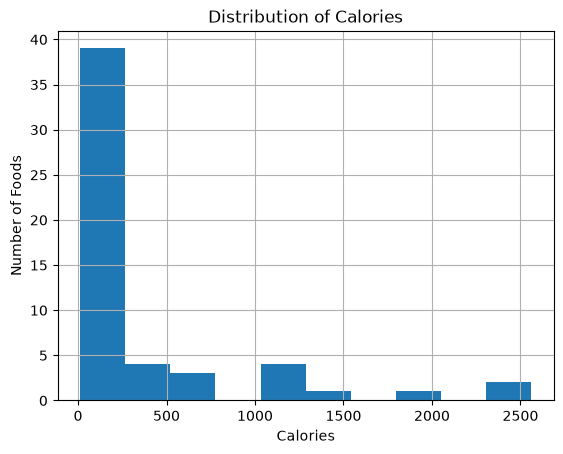

In [60]:
import matplotlib.pyplot as plt

food_data["calories"].hist()

plt.title("Distribution of Calories")
plt.xlabel("Calories")
plt.ylabel("Number of Foods")

plt.show()

### Calories Distribution

This graph shows how calories are distributed across the foods in the dataset. Most foods are grouped within a certain calorie range, while some foods have much higher calorie values.

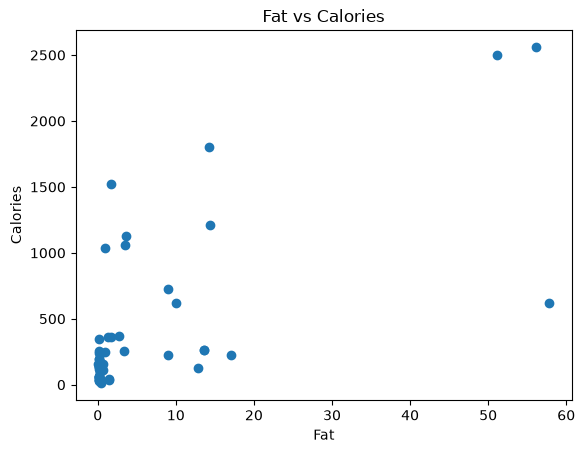

In [61]:
plt.scatter(food_data["fat"], food_data["calories"])

plt.title("Fat vs Calories")
plt.xlabel("Fat")
plt.ylabel("Calories")

plt.show()

### Fat and Calories

This graph shows the relationship between fat and calories. Foods with more fat generally appear to have higher calorie values.

## Data Preparation and Feature Selection

I selected only Foundation Foods from the USDA dataset and combined the food and nutrient data using the food ID.

I selected protein, carbohydrates, fat, fiber, and sodium as features and calories as the target variable.

Rows with missing values were removed. After cleaning, 54 foods remained in the dataset.

## Training and Testing

I will use protein, carbohydrates, fat, fiber, and sodium to predict calories.

The data will be split into training and testing sets so the model can be evaluated on data it has not seen before.

In [62]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
from sklearn.model_selection import train_test_split

X = food_data[["protein", "carbs", "fat", "fiber", "sodium"]]
y = food_data["calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (43, 5)
Testing size: (11, 5)


In [64]:
from sklearn.metrics import mean_absolute_error

baseline_prediction = [y_train.mean()] * len(y_test)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 353.84566596194503


In [65]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 290.30605043786494


In [66]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_predictions)

print("KNN Regression MAE:", knn_mae)

KNN Regression MAE: 163.07272727272726


In [67]:
print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)
print("KNN Regression MAE:", knn_mae)

Baseline MAE: 353.84566596194503
Linear Regression MAE: 290.30605043786494
KNN Regression MAE: 163.07272727272726


## Model Comparison

The models were compared using Mean Absolute Error (MAE). A lower MAE means the predictions are closer to the actual calorie values.

- Baseline MAE: 353.85
- Linear Regression MAE: 290.31
- KNN Regression MAE: 163.07

KNN Regression performed the best because it had the lowest MAE. Its predictions were off by about 163 calories on average.

Linear Regression performed better than the baseline, but not as well as KNN.

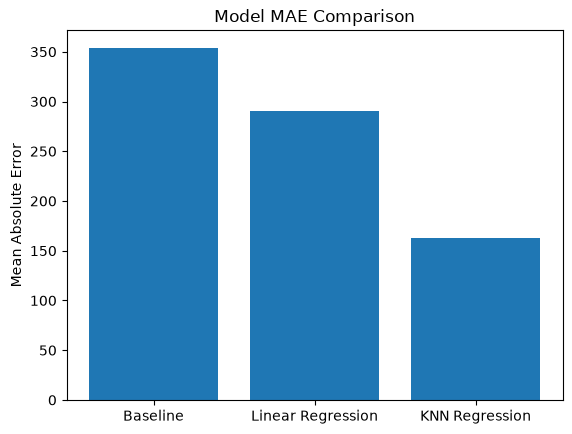

In [68]:
models = ["Baseline", "Linear Regression", "KNN Regression"]
mae_scores = [baseline_mae, linear_mae, knn_mae]

plt.bar(models, mae_scores)

plt.title("Model MAE Comparison")
plt.ylabel("Mean Absolute Error")

plt.show()

### Model Evaluation

The KNN Regression model had the lowest error, so it was selected as the better model for this dataset.

However, the dataset is small, so the results may change if more food data is added.

In [69]:
results = pd.DataFrame({
    "Actual Calories": y_test,
    "Predicted Calories": knn_predictions
})

results.head(10)

,Actual Calories,Predicted Calories
37,196.0,151.0
168,258.0,117.0
167,97.0,104.4
27,1130.0,912.4
155,44.0,94.2
16,29.0,896.4
35,141.0,164.8
171,61.0,117.0
10,620.0,751.8
104,34.0,164.8


## Model Interpretation

The table compares the actual calorie values with the calories predicted by the KNN model.

Some predictions are close to the actual values, while others have larger differences. This shows that the model can identify some patterns in the nutrition data, but it is not perfectly accurate.

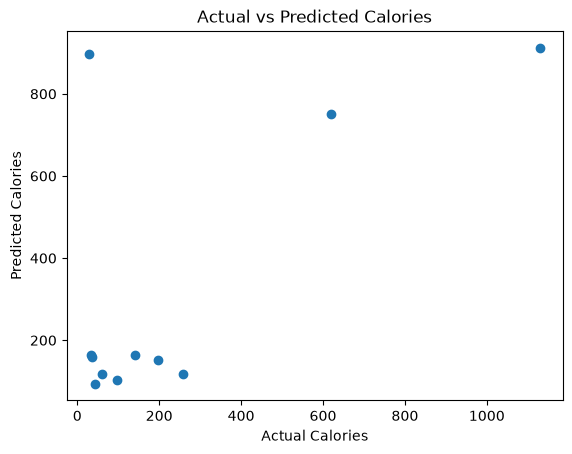

In [70]:
plt.scatter(y_test, knn_predictions)

plt.title("Actual vs Predicted Calories")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.show()

### Actual vs Predicted Calories

Points closer to a straight diagonal pattern represent better predictions. The graph shows that the model captures some of the relationship between nutritional information and calories, but there are still prediction errors.

## Limitations, Ethics, and Reflection

One limitation of this project is the small dataset size. After cleaning the data, only a limited number of foods remained.

The dataset may also not represent every type of food equally. Some food categories may be more common than others.

Incorrect predictions could give someone the wrong estimate of a food's calories. Because of this, the model should not replace official nutrition labels or professional dietary advice.

With more data, I would include more foods and additional nutritional features. I would also test other regression models to see if prediction accuracy improves.

## Code and AI Transparency

The code for this project was created in Python using pandas, matplotlib, and scikit-learn.

The dataset came from USDA FoodData Central.

Generative AI was used to help explain concepts, troubleshoot code errors, and organize the project. All code was reviewed and run by me.

### Code

The full Jupyter Notebook for this project is available in my GitHub repository.

### References

National Institute of Environmental Health Sciences. (n.d.). *Nutrition, health, and your environment*. National Institutes of Health.

National Academies of Sciences, Engineering, and Medicine. (2023). *Dietary reference intakes for energy*. National Academies Press.

U.S. Department of Agriculture & U.S. Department of Health and Human Services. (2020). *Dietary Guidelines for Americans, 2020–2025* (9th ed.).